In [1]:
# Import the dependencies
import pandas as pd
import numpy as np
import datetime

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ORM Stuff
from sqlalchemy import create_engine, inspect, text, func
from sqlalchemy.orm import Session
from sqlalchemy.ext.automap import automap_base

# Create a reference to the file.
# database_path = Path("C:\Users\dubja\OneDrive\Documents\Bootcamp Oct2024\Github_HW\Crowdfunding_ETL\Crowdfunding_ETL\Jason_Work\campaign.csv")

In [2]:
USERNAME = "postgres"
PASSWORD = "postgres"
HOST = "localhost"
PORT = 5432
DATABASE = "Project_2_DB"
connection_str = f"postgresql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"

# Create Engine
engine = create_engine(connection_str)

In [3]:
conn=engine.connect()

In [4]:
conn.execute(text('select * from contacts')).all()

[(4661, 'Cecilia', 'Velasco', 'cecilia.velasco@rodrigues.fr'),
 (3765, 'Mariana', 'Ellis', 'mariana.ellis@rossi.org'),
 (4187, 'Sofie', 'Woods', 'sofie.woods@riviere.com'),
 (4941, 'Jeanette', 'Iannotti', 'jeanette.iannotti@yahoo.com'),
 (2199, 'Samuel', 'Sorgatz', 'samuel.sorgatz@gmail.com'),
 (5650, 'Socorro', 'Luna', 'socorro.luna@hotmail.com'),
 (5889, 'Carolina', 'Murray', 'carolina.murray@knight.com'),
 (4842, 'Kayla', 'Moon', 'kayla.moon@yahoo.de'),
 (3280, 'Ariadna', 'Geisel', 'ariadna.geisel@rangel.com'),
 (5468, 'Danielle', 'Ladeck', 'danielle.ladeck@scalfaro.net'),
 (3064, 'Tatiana', 'Thompson', 'tatiana.thompson@hunt.net'),
 (4904, 'Caleb', 'Benavides', 'caleb.benavides@rubio.com'),
 (1299, 'Sandra', 'Hardy', 'sandra.hardy@web.de'),
 (5602, 'Lotti', 'Morris', 'lotti.morris@yahoo.co.uk'),
 (5753, 'Reinhilde', 'White', 'reinhilde.white@voila.fr'),
 (4495, 'Kerry', 'Patel', 'kerry.patel@hutchinson.com'),
 (4269, 'Sophie', 'Antoine', 'sophie.antoine@andersen.com'),
 (2226, 'Mar

In [5]:
conn.execute(text('select * from campaign')).all()

[(147, 4661, 'Baldwin, Riley and Jackson', 'Pre-emptive tertiary standardization', 100, 0, 'failed', 0, 'CA', 'CAD', datetime.date(2020, 2, 13), datetime.date(2021, 3, 1), 'cat1', 'subcat1'),
 (1621, 3765, 'Odom Inc', 'Managed bottom-line architecture', 1400, 14560, 'successful', 158, 'US', 'USD', datetime.date(2021, 1, 25), datetime.date(2021, 5, 25), 'cat2', 'subcat2'),
 (1812, 4187, 'Melton, Robinson and Fritz', 'Function-based leadingedge pricing structure', 108400, 142523, 'successful', 1425, 'AU', 'AUD', datetime.date(2020, 12, 17), datetime.date(2021, 12, 30), 'cat3', 'subcat3'),
 (2156, 4941, 'Mcdonald, Gonzalez and Ross', 'Vision-oriented fresh-thinking conglomeration', 4200, 2477, 'failed', 24, 'US', 'USD', datetime.date(2021, 10, 21), datetime.date(2022, 1, 17), 'cat2', 'subcat2'),
 (1365, 2199, 'Larson-Little', 'Proactive foreground core', 7600, 5265, 'failed', 53, 'US', 'USD', datetime.date(2020, 12, 21), datetime.date(2021, 8, 23), 'cat4', 'subcat4'),
 (2057, 5650, 'Harri

In [10]:
#Create the query
query = """
SELECT
    cf_id,
    contact_id,
    company_name,
    description,
    goal,
    pledged,
    outcome,
    country,
    currency
FROM
    campaign
WHERE
    outcome IN ('failed', 'successful')
ORDER BY
    contact_id ASC, company_name ASC, outcome ASC, currency ASC;
"""

df = pd.read_sql(query, conn)  

In [11]:
df.head()

,cf_id,contact_id,company_name,description,goal,pledged,outcome,country,currency
0,1006,1235,"Hale, Pearson and Jenkins",Upgradable attitude-oriented project,97200,55372,failed,US,USD
1,2963,1241,"Brooks, Jones and Ingram",Triple-buffered explicit methodology,9900,1870,failed,US,USD
2,805,1243,Carney-Anderson,Digitized 5thgeneration knowledgebase,1000,4257,successful,US,USD
3,2403,1244,Rodriguez-West,Automated optimal function,7000,1744,failed,US,USD
4,358,1249,Sandoval-Powell,Phased holistic implementation,84400,8092,failed,US,USD


In [12]:
outcome_counts = df['outcome'].value_counts()

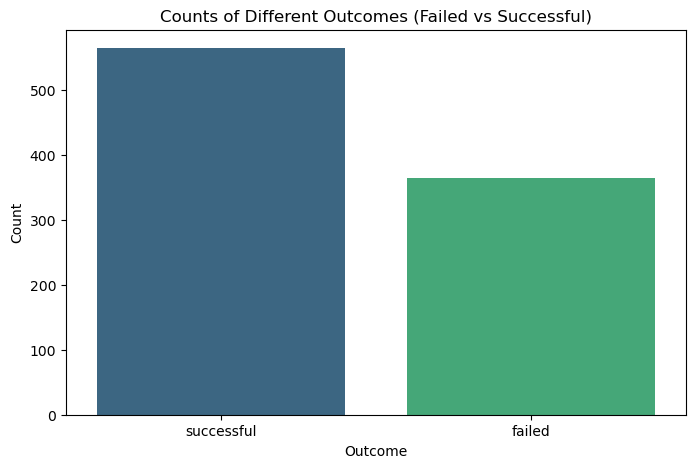

In [14]:
# Create a simple bar plot using Matplotlib
plt.figure(figsize=(8, 5))

# Use hue argument to assign a color palette based on the outcome categories
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette="viridis")

# Add labels and title
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Counts of Different Outcomes (Failed vs Successful)')

# Display the plot
plt.show()